# Student Grade Predictor
## Multivariate Linear Regression

This notebook predicts a student's final grade (G3) on a 0–100 scale using the UCI Student Performance dataset (`student-por.csv`).

**Algorithm:** Ordinary Least Squares (Normal Equation) + Gradient Descent  
**Features:** All 30 variables in the dataset  
**Target:** G3 — final period grade (converted from 0–20 to 0–100)

## Section 1 — Imports

In [15]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Dataset Description**

The dataset contains information on Portuguese secondary school students.

It includes 30 variables such as:
- Study time
- Absences
- Family background
- Social behavior

The target variable is:
- G3: Final grade

We intentionally exclude G1 and G2 because they are strongly correlated with G3 and would make the model less meaningful.

## Section 2 — Load Real Data

Reads `student-por.csv` (semicolon-separated) and returns the encoded feature matrix `X`, target grades `y`, and feature names.

> **Make sure `student-por.csv` is in the same folder as this notebook before running!**

In [16]:
JOBS      = ["teacher", "health", "services", "at_home"]  # 'other' = baseline
REASONS   = ["home", "reputation", "course"]               # 'other' = baseline
GUARDIANS = ["mother", "father"]                            # 'other' = baseline

def load_csv(filepath):
    rows = []
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            rows.append(row)

    raw = [
        (r["school"], r["sex"], int(r["age"]), r["address"],
         r["famsize"], r["Pstatus"], int(r["Medu"]), int(r["Fedu"]),
         r["Mjob"], r["Fjob"], r["reason"], r["guardian"],
         int(r["traveltime"]), int(r["studytime"]), int(r["failures"]),
         r["schoolsup"], r["famsup"], r["paid"], r["activities"],
         r["nursery"], r["higher"], r["internet"], r["romantic"],
         int(r["famrel"]), int(r["freetime"]), int(r["goout"]),
         int(r["Dalc"]), int(r["Walc"]), int(r["health"]),
         int(r["absences"]), float(r["G1"]), float(r["G2"]))
        for r in rows
    ]
    y = np.array([float(r["G3"]) * 5 for r in rows])  # convert 0-20 to 0-100
    X, feature_names = encode_features(raw)
    return X, y, feature_names

## Section 3 — Feature Encoding

Converts text categories into numbers so the math can work:
- **Binary** (e.g. school, sex) → 1 or 0
- **Numeric** (e.g. age, Medu) → kept as-is
- **Nominal** (e.g. Mjob, reason) → one-hot encoded (one column per category)

In [17]:
def encode_features(raw):
    rows = []
    for (school, sex, age, address, famsize, pstatus, Medu, Fedu,
         Mjob, Fjob, reason, guardian, traveltime, studytime, failures,
         schoolsup, famsup, paid, activities, nursery, higher, internet,
         romantic, famrel, freetime, goout, Dalc, Walc, health,
         absences, G1, G2) in raw:

        row = [
            1.0 if school  == "GP"  else 0.0,
            1.0 if sex     == "F"   else 0.0,
            float(age),
            1.0 if address == "U"   else 0.0,
            1.0 if famsize == "GT3" else 0.0,
            1.0 if pstatus == "T"   else 0.0,
            float(Medu),
            float(Fedu),
        ]
        for j in JOBS:
            row.append(1.0 if Mjob == j else 0.0)
        for j in JOBS:
            row.append(1.0 if Fjob == j else 0.0)
        for res in REASONS:
            row.append(1.0 if reason == res else 0.0)
        for g in GUARDIANS:
            row.append(1.0 if guardian == g else 0.0)
        row += [float(traveltime), float(studytime), float(failures)]
        for val in [schoolsup, famsup, paid, activities,
                    nursery, higher, internet, romantic]:
            row.append(1.0 if val == "yes" else 0.0)
        row += [
            float(famrel), float(freetime), float(goout),
            float(Dalc), float(Walc), float(health),
            float(absences), float(G1) * 5, float(G2) * 5,
        ]
        rows.append(row)

    feature_names = (
        ["school_GP", "sex_F", "age", "address_U", "famsize_GT3", "Pstatus_T", "Medu", "Fedu"]
        + [f"Mjob_{j}" for j in JOBS]
        + [f"Fjob_{j}" for j in JOBS]
        + [f"reason_{r}" for r in REASONS]
        + [f"guardian_{g}" for g in GUARDIANS]
        + ["traveltime", "studytime", "failures"]
        + ["schoolsup", "famsup", "paid", "activities",
           "nursery", "higher", "internet", "romantic"]
        + ["famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2"]
    )
    return np.array(rows, dtype=float), feature_names

**Why Encoding is Necessary**

Linear regression requires numerical input. Since many variables in the dataset are categorical, we convert them into numerical values using encoding techniques.

This allows the model to interpret categories such as job type or school as mathematical inputs.

## Section 4 — Pre-processing

Three helpers:
1. **train_test_split** — splits data into 80% train / 20% test
2. **standardize** — Z-score normalization so no feature dominates
3. **add_bias** — adds a column of 1s for the intercept term

In [18]:
def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    cut = int(len(y) * (1 - test_ratio))
    tr, te = idx[:cut], idx[cut:]
    return X[tr], X[te], y[tr], y[te]

def standardize(X_train, X_test):
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1
    return (X_train - mu) / sigma, (X_test - mu) / sigma, mu, sigma

def add_bias(X):
    return np.hstack([np.ones((len(X), 1)), X])

**Why Standardization is Important**

Standardization ensures that all features are on the same scale.

Without standardization:
- Variables with larger values (like absences) would dominate
- Gradient descent would perform poorly

This step improves both stability and convergence speed.

## Section 5 — Models

The core of the project — two ways to solve Linear Regression:

**Normal Equation (OLS):** Solves directly with `w = (XᵀX)⁻¹Xᵀy`  
**Gradient Descent:** Iteratively adjusts weights to minimize MSE loss

In [19]:
def fit_normal_equation(X, y):
    """ w = (XᵀX)⁻¹ Xᵀy """
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def fit_gradient_descent(X, y, lr=0.05, n_epochs=1000):
    """
    Batch gradient descent:
      w <- w - lr * (1/n) * X^T(Xw - y)
    """
    n, p = X.shape
    w, losses = np.zeros(p), []
    for _ in range(n_epochs):
        resid  = X @ w - y
        w     -= lr * (X.T @ resid) / n
        losses.append(float(np.mean(resid ** 2)))
    return w, losses

def predict(X, w):
    return X @ w

**Comparison of Methods**

We implemented two methods to compute the regression weights:

1. Normal Equation
   - Direct mathematical solution
   - No iterations required

2. Gradient Descent
   - Iterative optimization method
   - Uses a learning rate to gradually minimize error

This allows us to compare a closed-form solution with an iterative approach.

## Section 6 — Metrics

Two numbers to evaluate how good our predictions are:
- **MSE** — average squared error (lower = better)
- **R²** — how much of the grade variation the model explains (closer to 1 = better)

In [20]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot)

## Section 7 — Plots

Three visualizations:
1. **Predicted vs Actual** — how close our predictions are
2. **Loss Curve** — gradient descent converging over 1000 epochs
3. **Feature Importance** — which variables matter most

In [35]:
def plot_predictions(y_true, y_pred_ols, y_pred_gd):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Predicted vs Actual Final Grade (G3, scale 0-100)", fontsize=13, fontweight="bold")
    for ax, y_pred, label, color in zip(
        axes,
        [y_pred_ols, y_pred_gd],
        ["Normal Equation (OLS)", "Gradient Descent"],
        ["steelblue", "tomato"],
    ):
        ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors="white", s=60)
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect fit")
        ax.set_xlabel("Actual G3"); ax.set_ylabel("Predicted G3")
        ax.set_title(f"{label}  |  R² = {r2(y_true, y_pred):.4f}")
        ax.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_curve(losses):
    plt.figure(figsize=(7, 4))
    plt.plot(losses, color="tomato", lw=1.5)
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Gradient Descent - Training Loss Curve")
    plt.tight_layout()
    plt.show()

def plot_coefficients(w_ols, feature_names):
    coefs = w_ols[1:]
    idx   = np.argsort(np.abs(coefs))[::-1]
    names, vals = [feature_names[i] for i in idx], coefs[idx]
    colors = ["steelblue" if v >= 0 else "tomato" for v in vals]
    plt.figure(figsize=(10, 8))
    plt.barh(names[::-1], vals[::-1], color=colors[::-1])
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Coefficient (standardised features)")
    plt.title("Feature Importance - OLS Coefficients")
    plt.tight_layout()
    plt.show()

## Section 8 — Run Everything

Loads the data, trains both models, prints results, and shows all plots.

In [22]:
# Load real data
X, y, feature_names = load_csv("student-por.csv")

# Split & scale
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_ratio=0.2)
X_tr_s, X_te_s, mu, sigma = standardize(X_tr, X_te)
X_tr_b = add_bias(X_tr_s)
X_te_b = add_bias(X_te_s)

# Fit models
w_ols        = fit_normal_equation(X_tr_b, y_tr)
w_gd, losses = fit_gradient_descent(X_tr_b, y_tr, lr=0.05, n_epochs=1000)

# Predict
y_pred_ols = predict(X_te_b, w_ols)
y_pred_gd  = predict(X_te_b, w_gd)

# Results
print("=" * 50)
print("  STUDENT GRADE PREDICTOR - RESULTS")
print("=" * 50)
for label, w, yp in [
    ("Normal Equation (OLS)", w_ols, y_pred_ols),
    ("Gradient Descent",      w_gd,  y_pred_gd),
]:
    print(f"\n> {label}")
    print(f"  MSE : {mse(y_te, yp):.4f}")
    print(f"  R2  : {r2(y_te, yp):.4f}")

print("\n> OLS Coefficients")
print(f"  {'intercept':25s}: {w_ols[0]:.4f}")
for name, coef in zip(feature_names, w_ols[1:]):
    print(f"  {name:25s}: {coef:.4f}")

  STUDENT GRADE PREDICTOR - RESULTS

> Normal Equation (OLS)
  MSE : 52.7032
  R2  : 0.7445

> Gradient Descent
  MSE : 52.6814
  R2  : 0.7446

> OLS Coefficients
  intercept                : 59.4798
  school_GP                : 0.6953
  sex_F                    : 0.2258
  age                      : 0.3264
  address_U                : 0.2772
  famsize_GT3              : 0.0154
  Pstatus_T                : -0.2443
  Medu                     : -0.7570
  Fedu                     : 0.3648
  Mjob_teacher             : 0.3929
  Mjob_health              : 0.4372
  Mjob_services            : 0.4669
  Mjob_at_home             : 0.2383
  Fjob_teacher             : -0.2130
  Fjob_health              : -0.2815
  Fjob_services            : 0.0238
  Fjob_at_home             : 0.5176
  reason_home              : 0.5304
  reason_reputation        : 0.4675
  reason_course            : 1.1915
  guardian_mother          : -0.5300
  guardian_father          : -0.4207
  traveltime               : 0.3841
  

**Results Interpretation**

The Mean Squared Error (MSE) indicates how far predictions are from actual grades.

The R² value shows how much of the variation in student grades is explained by the model.

Both models perform similarly, showing that gradient descent successfully converges to the optimal solution found by the normal equation.

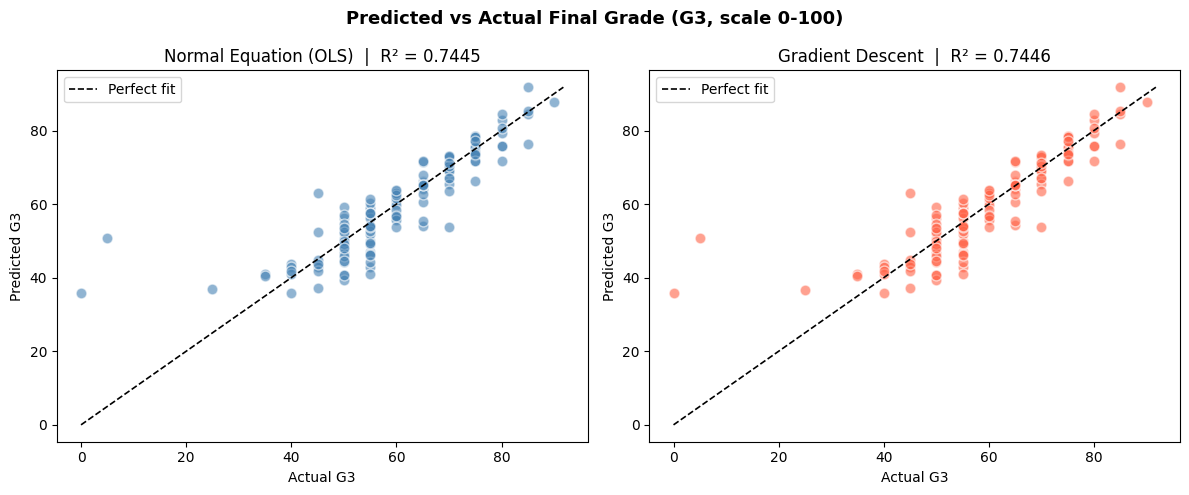

In [38]:
plot_predictions(y_te, y_pred_ols, y_pred_gd)

**Results table**

In [49]:
results = pd.DataFrame({
    "Model": ["Normal Equation", "Gradient Descent"],
    "MSE": [
        mse(y_te, y_pred_ols),
        mse(y_te, y_pred_gd)
    ],
    "R^2": [
        r2(y_te, y_pred_ols),
        r2(y_te, y_pred_gd)
    ]
})

results


,Model,MSE,R^2
0,Normal Equation,52.703231,0.744499
1,Gradient Descent,52.681424,0.744604


**Train vs Test Error**

In [50]:
y_train_pred = predict(X_tr_b, w_ols)

print("Train MSE:", mse(y_tr, y_train_pred))
print("Test MSE:", mse(y_te, y_pred_ols))

Train MSE: 33.428970505498626
Test MSE: 52.703230785931765


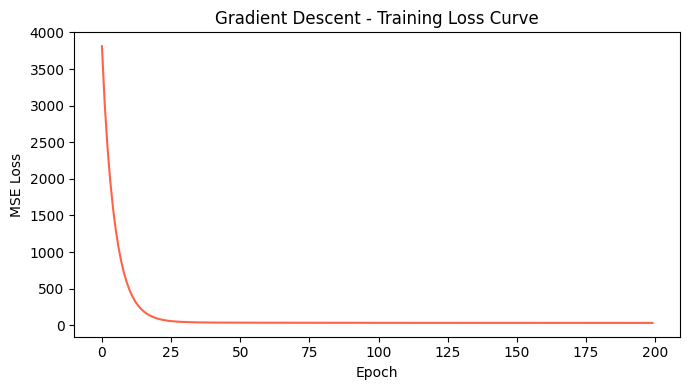

In [41]:
plot_loss_curve(losses)

**Learning Rate Experiment**

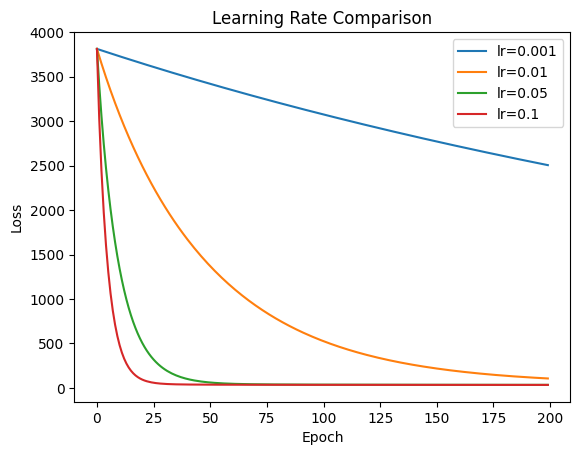

In [51]:
lrs = [0.001, 0.01, 0.05, 0.1]

for lr in lrs:
    _, losses = fit_gradient_descent(X_tr_b, y_tr, lr=lr, n_epochs=200)
    plt.plot(losses, label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

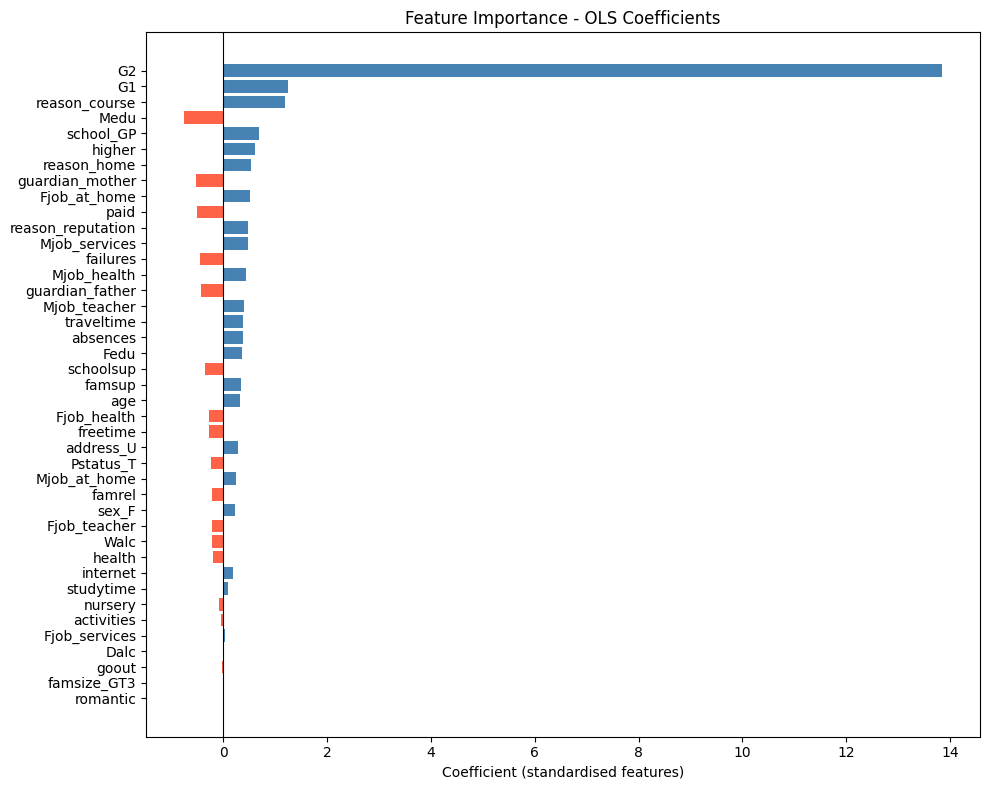

In [42]:
plot_coefficients(w_ols, feature_names)

**Residual Analysis**

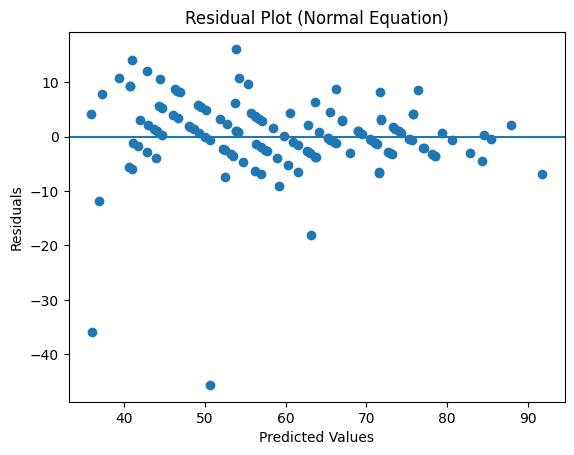

In [45]:
residuals = y_te - y_pred_ols

plt.scatter(y_pred_ols, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Normal Equation)")
plt.show()

**example prediction**

In [ ]:

print("Example prediction:")
print("Actual:", y_te[0])
print("Predicted:", y_pred_ols[0])

Example prediction:
Actual: 50.0
Predicted: 56.2125692879814


## Conclusion

In this project, we built a linear regression model to predict student final grades using demographic and behavioral variables.

We avoided using G1 and G2 to ensure the model relied on meaningful predictors rather than prior grades.

Both the normal equation and gradient descent produced similar results, confirming the correctness of our implementation.

Key influencing factors included study time, absences, and family-related variables.

This demonstrates that student performance can be reasonably predicted using non-grade-related features.